In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
cd /content/drive/MyDrive/Downstream/
ls

clean_aggregated.parquet
clean_aggregated_with_sa_tokens.parquet
RS01_LanguageModelEmbeddingsTransferLearningForDownstreamTask_Solubility.ipynb
soluprotmutdb_results.csv
soluprotmutdb_results.xlsx


In [ ]:
import pandas as pd

# Path to the CSV file on Google Drive
csv_file_path = '/content/drive/MyDrive/Downstream/soluprotmutdb_results.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

print(f"'{csv_file_path}' loaded into DataFrame 'df'.")
print(f"Shape of df: {df.shape}")
print("First 5 rows of df:")
print(df.head(2))


'/content/drive/MyDrive/Downstream/soluprotmutdb_results.csv' loaded into DataFrame 'df'.
Shape of df: (32940, 32)
First 5 rows of df:
          spmdb_ac mutations label solubility_effect  levels  \
0  WH.GFP.LGK.100A     R100A     -                --       5   
1  WH.GFP.LGK.100C     R100C     N                 N       5   

                protein_name             species ec_number uniprot_id pdb_id  \
0  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
1  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   

   ... solubility_change host_cell  host_strain  system_type  assay_type  \
0  ...         -0.529848   E. coli    BL21(DE3)      IN_VIVO    GFP+FACS   
1  ...         -0.025050   E. coli    BL21(DE3)      IN_VIVO    GFP+FACS   

   temperature  pH  notes                        doi  \
0         30.0 NaN    NaN  10.1021/acssynbio.8b00486   
1         30.0 NaN    NaN  10.1021/acssynbio.8b00486   

                                 

/tmp/ipython-input-1257310665.py:7: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


In [ ]:
df.head(2)

,spmdb_ac,mutations,label,solubility_effect,levels,protein_name,species,ec_number,uniprot_id,pdb_id,...,solubility_change,host_cell,host_strain,system_type,assay_type,temperature,pH,notes,doi,sequence
0,WH.GFP.LGK.100A,R100A,-,--,5,LGK (Levoglucosan kinase),Lipomyces starkeyi,NaN,B3VI55,4ZFV,...,-0.529848,E. coli,BL21(DE3),IN_VIVO,GFP+FACS,30.0,NaN,NaN,10.1021/acssynbio.8b00486,MPIATSTGDNVLDFTVLGLNSGTSMDGIDCALCHFYQKTPDAPMEF...
1,WH.GFP.LGK.100C,R100C,N,N,5,LGK (Levoglucosan kinase),Lipomyces starkeyi,NaN,B3VI55,4ZFV,...,-0.025050,E. coli,BL21(DE3),IN_VIVO,GFP+FACS,30.0,NaN,NaN,10.1021/acssynbio.8b00486,MPIATSTGDNVLDFTVLGLNSGTSMDGIDCALCHFYQKTPDAPMEF...


In [ ]:
initial_rows = len(df)
df.dropna(subset=['solubility_change'], inplace=True)
rows_dropped = initial_rows - len(df)
print(f"Dropped {rows_dropped} rows where 'solubility_change' was NaN.")
print(f"New shape of df: {df.shape}")

Dropped 532 rows where 'solubility_change' was NaN.
New shape of df: (32408, 32)


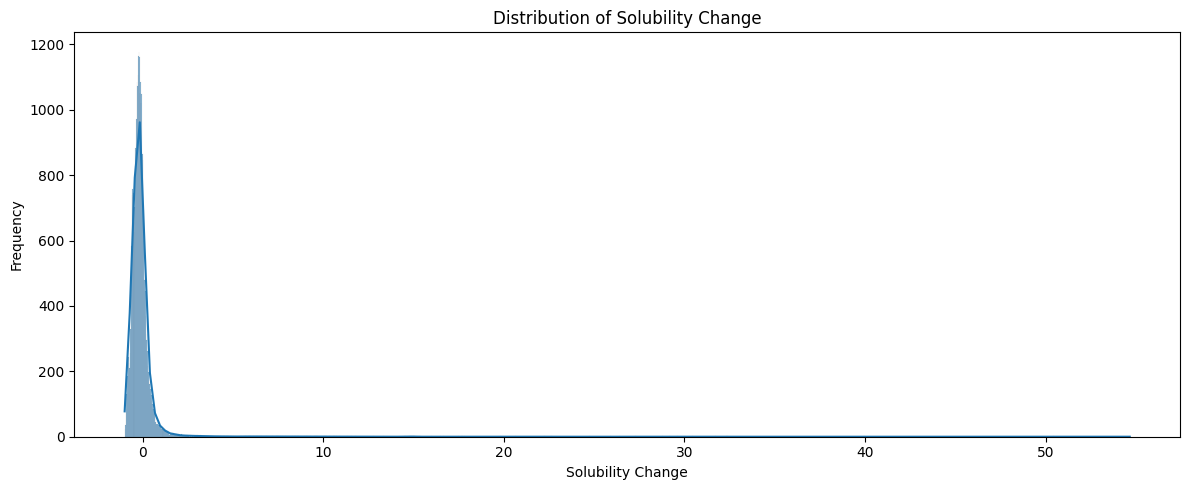

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(df['solubility_change'], kde=True)
plt.title('Distribution of Solubility Change')
plt.xlabel('Solubility Change')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

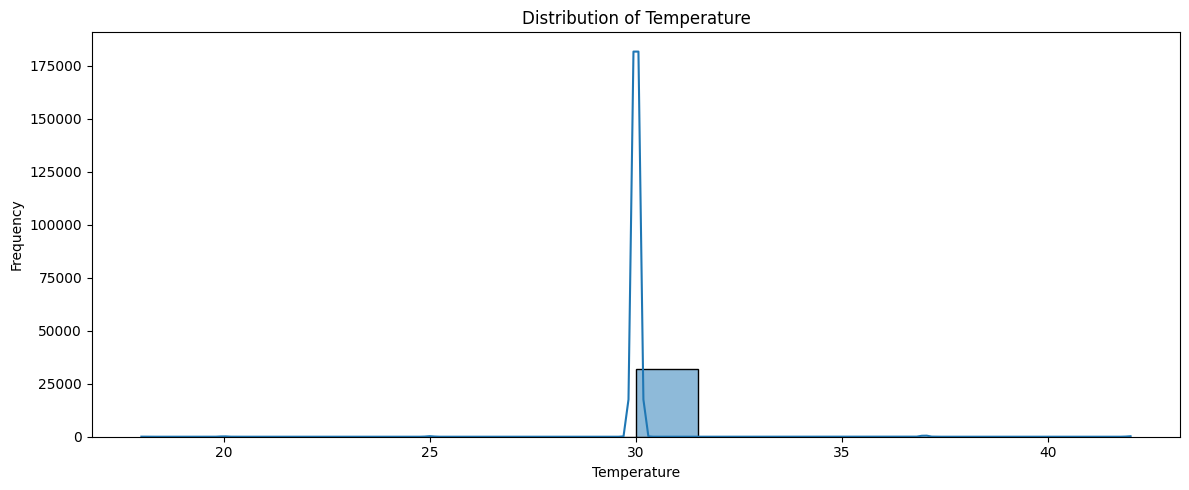

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(df['temperature'], kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

2**Reasoning**:
I will use the `duplicated()` method on the `df` DataFrame with the specified subset of columns and `keep=False` to identify all duplicate combinations of 'uniprot_id' and 'mutations', storing the result in a new column.



In [ ]:
df['is_duplicate_combination'] = df.duplicated(subset=['uniprot_id', 'mutations'], keep=False)
print(f"Added 'is_duplicate_combination' column. Number of duplicate combinations found: {df['is_duplicate_combination'].sum()}")
print(df[['uniprot_id', 'mutations', 'is_duplicate_combination']].head())

Added 'is_duplicate_combination' column. Number of duplicate combinations found: 25722
  uniprot_id mutations  is_duplicate_combination
0     B3VI55     R100A                      True
1     B3VI55     R100C                      True
2     B3VI55     R100D                      True
3     B3VI55     R100F                     False
4     B3VI55     R100G                      True


## Extract Data for Duplicate Groups

### Subtask:
Filter the DataFrame to include only the rows that are part of these duplicate groups. Select relevant columns like 'uniprot_id', 'mutations', and 'solubility_change'.


In [ ]:
df_duplicates = df[df['is_duplicate_combination'] == True] # [['uniprot_id', 'mutations', 'solubility_change','sequences']]
print(f"Shape of df_duplicates: {df_duplicates.shape}")
print("First 5 rows of df_duplicates:")
print(df_duplicates.head())

Shape of df_duplicates: (25722, 33)
First 5 rows of df_duplicates:
          spmdb_ac mutations label solubility_effect  levels  \
0  WH.GFP.LGK.100A     R100A     -                --       5   
1  WH.GFP.LGK.100C     R100C     N                 N       5   
2  WH.GFP.LGK.100D     R100D     -                --       5   
4  WH.GFP.LGK.100G     R100G     -                --       5   
5  WH.GFP.LGK.100H     R100H     N                 N       5   

                protein_name             species ec_number uniprot_id pdb_id  \
0  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
1  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
2  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
4  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
5  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   

   ... host_cell host_strain  system_type  assay_type  temperature 

In [ ]:
df_duplicates['group_identifier'] = df_duplicates['uniprot_id'] + '_' + df_duplicates['mutations']
print("Added 'group_identifier' column to df_duplicates.")
print(df_duplicates.head())

Added 'group_identifier' column to df_duplicates.
          spmdb_ac mutations label solubility_effect  levels  \
0  WH.GFP.LGK.100A     R100A     -                --       5   
1  WH.GFP.LGK.100C     R100C     N                 N       5   
2  WH.GFP.LGK.100D     R100D     -                --       5   
4  WH.GFP.LGK.100G     R100G     -                --       5   
5  WH.GFP.LGK.100H     R100H     N                 N       5   

                protein_name             species ec_number uniprot_id pdb_id  \
0  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
1  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
2  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
4  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   
5  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   4ZFV   

   ... host_strain system_type  assay_type  temperature  pH  notes  \
0  ...   BL21(

/tmp/ipython-input-543047833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_duplicates['group_identifier'] = df_duplicates['uniprot_id'] + '_' + df_duplicates['mutations']


**Reasoning**:
To prepare for visualization, I need to count the number of unique duplicate groups to decide if sampling is necessary, and then extract the data for these groups.



In [ ]:
import numpy as np
unique_duplicate_groups = df_duplicates['group_identifier'].unique()
num_unique_duplicate_groups = len(unique_duplicate_groups)

print(f"Number of unique duplicate groups: {num_unique_duplicate_groups}")

# If there are too many unique groups, we'll sample a subset for visualization
if num_unique_duplicate_groups > 20:
    sample_groups = np.random.choice(unique_duplicate_groups, 20, replace=False)
    df_plot = df_duplicates[df_duplicates['group_identifier'].isin(sample_groups)].copy()
    print(f"Selected a sample of 20 groups for visualization.")
else:
    df_plot = df_duplicates.copy()
    print("All unique groups will be plotted.")

print(f"Shape of df_plot: {df_plot.shape}")
print("First 5 rows of df_plot:")
print(df_plot.head())

Number of unique duplicate groups: 10127
Selected a sample of 20 groups for visualization.
Shape of df_plot: (51, 34)
First 5 rows of df_plot:
             spmdb_ac mutations label solubility_effect  levels  \
875   WH.GFP.LGK.152I     F152I     -                 -       5   
890   WH.GFP.LGK.153H     R153H     N                 N       5   
1492  WH.GFP.LGK.187G     I187G     -                 -       5   
1526   WH.GFP.LGK.18I      G18I     -                 -       5   
2488   WH.GFP.LGK.24F      S24F     -                 -       5   

                   protein_name             species ec_number uniprot_id  \
875   LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   
890   LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   
1492  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   
1526  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55   
2488  LGK (Levoglucosan kinase)  Lipomyces starkeyi       NaN     B3VI55  

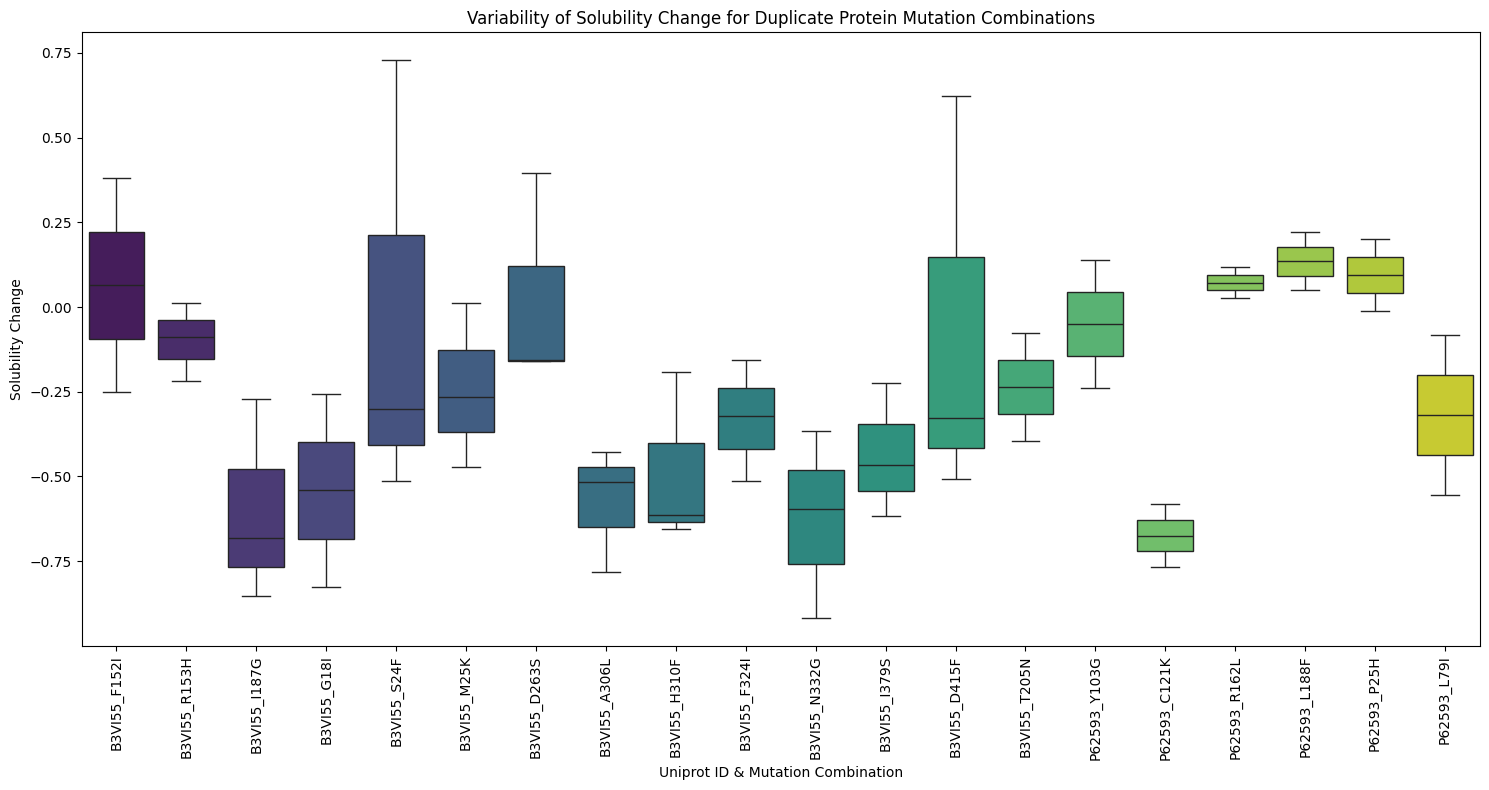

Box plots visualizing the variability of 'solubility_change' for each duplicate group have been generated, addressing FutureWarning.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger figure size for better readability, especially if many groups are plotted
plt.figure(figsize=(15, 8))

# Create the box plot, addressing the FutureWarning
sns.boxplot(x='group_identifier', y='solubility_change', data=df_plot, hue='group_identifier', palette='viridis', legend=False)

# Add labels and title
plt.xlabel('Uniprot ID & Mutation Combination')
plt.ylabel('Solubility Change')
plt.title('Variability of Solubility Change for Duplicate Protein Mutation Combinations')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("Box plots visualizing the variability of 'solubility_change' for each duplicate group have been generated, addressing FutureWarning.")

In [ ]:
df_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25722 entries, 0 to 32888
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   spmdb_ac                  25722 non-null  object 
 1   mutations                 25722 non-null  object 
 2   label                     25722 non-null  object 
 3   solubility_effect         25722 non-null  object 
 4   levels                    25722 non-null  int64  
 5   protein_name              25722 non-null  object 
 6   species                   25722 non-null  object 
 7   ec_number                 7394 non-null   object 
 8   uniprot_id                25722 non-null  object 
 9   pdb_id                    18338 non-null  object 
 10  interpro_entries          25722 non-null  object 
 11  chain                     18338 non-null  object 
 12  is_curated                25722 non-null  bool   
 13  pre_counts                25678 non-null  float64
 14  post_counts

In [ ]:
import pandas as pd
import numpy as np

def flag_clean_aggregate(df, group_col='sequence', target_col='solubility', sd_threshold=0.7):
    """
    Implements Flag-Clean-Aggregate logic for experimental replicates.

    1. Flag: Identifies groups with high Standard Deviation.
    2. Clean: Removes the single furthest outlier in high-SD groups (if N >= 3).
    3. Aggregate: Calculates the Median and returns a clean DataFrame.
    """

    # helper to clean a single group's outliers
    def clean_group(group):
        if len(group) >= 3 and group.std() > sd_threshold:
            # Find the value furthest from the median
            median = group.median()
            outlier_idx = (group - median).abs().idxmax()
            # Drop the single worst outlier
            group = group.drop(outlier_idx)
        return group

    # Create a copy to avoid modifying original data
    working_df = df.copy()

    # Step 1 & 2: Group and Clean outliers from noisy replicates
    # We apply the 'clean_group' function to each set of replicates
    cleaned_series = working_df.groupby(group_col)[target_col].apply(clean_group)

    # Step 3: Re-group and Aggregate (Median is most robust to error)
    # We also calculate the NEW SD and Count for tracking
    final_df = cleaned_series.groupby(group_col).agg(
        target_mean=('mean'),
        target_median=('median'),
        target_sd=('std'),
        replicate_count=('count')
    ).reset_index()

    # Optional: Flag remaining groups that are still too noisy
    final_df['high_noise_flag'] = final_df['target_sd'] > sd_threshold

    return final_df

# --- Usage Example ---
# df = pd.read_csv("experimental_results.csv")
# clean_df = flag_clean_aggregate(df, sd_threshold=0.5)

In [ ]:
import numpy as np

# Ensure 'group_identifier' is created for all rows in the main df
# This assumes df has already had NaN solubility_change rows dropped.
df['group_identifier'] = df['uniprot_id'] + '_' + df['mutations']

# Calculate IQR for solubility_change within each group_identifier from the full df
# Groups with single observations will have an IQR of 0 and will not be filtered out by > iqr_threshold (unless threshold is negative).
iqr_by_group = df.groupby('group_identifier')['solubility_change'].agg(lambda x: x.quantile(0.75) - x.quantile(0.25)).rename('iqr')

# Define a threshold for 'very high variability' (e.g., above the 75th percentile of all IQRs)
iqr_threshold = iqr_by_group.quantile(0.75)
print(f"IQR Threshold for high variability (75th percentile of IQRs): {iqr_threshold:.4f}")

# Identify groups with IQR above the threshold
high_variability_groups = iqr_by_group[iqr_by_group > iqr_threshold].index
print(f"Number of high variability groups identified: {len(high_variability_groups)}")

# Filter df to exclude high variability groups
df_filtered_variability = df.copy() #df[~df['group_identifier'].isin(high_variability_groups)]
print(f"Shape of df_filtered_variability after dropping high variability groups: {df_filtered_variability.shape}")

# Apply the flag_clean_aggregate function to the df_filtered_variability
# This will aggregate all groups including those with single observations.
# Outliers will only be cleaned for groups with >=3 replicates and high SD, as per flag_clean_aggregate logic.
clean_aggregated_df = flag_clean_aggregate(
    df_filtered_variability,
    group_col='group_identifier',
    target_col='solubility_change',
    sd_threshold=0.7 # Example threshold, can be adjusted
)

print("Cleaned and aggregated DataFrame created.")
print(f"Shape of clean_aggregated_df: {clean_aggregated_df.shape}")
print("First 5 rows of clean_aggregated_df:")
print(clean_aggregated_df.head())
print("\nInfo of clean_aggregated_df:")
clean_aggregated_df.info()

IQR Threshold for high variability (75th percentile of IQRs): 0.2078
Number of high variability groups identified: 4203
Shape of df_filtered_variability after dropping high variability groups: (32408, 34)
Cleaned and aggregated DataFrame created.
Shape of clean_aggregated_df: (16813, 6)
First 5 rows of clean_aggregated_df:
   group_identifier  target_mean  target_median  target_sd  replicate_count  \
0  A0A3G4RHW3_A112C    -0.236712      -0.236712        NaN                1   
1  A0A3G4RHW3_A112D    -0.240775      -0.240775        NaN                1   
2  A0A3G4RHW3_A112G    -0.096435      -0.096435        NaN                1   
3  A0A3G4RHW3_A112H    -0.425890      -0.425890        NaN                1   
4  A0A3G4RHW3_A112I    -0.375489      -0.375489        NaN                1   

   high_noise_flag  
0            False  
1            False  
2            False  
3            False  
4            False  

Info of clean_aggregated_df:
<class 'pandas.core.frame.DataFrame'>
RangeI

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(df['solubility_change'], kde=True)
plt.title('Distribution of Solubility Change')
plt.xlabel('Solubility Change')
plt.ylabel('Frequency')
plt.xlim(-5,50)
plt.tight_layout()
plt.show()



```
# This is formatted as code
```Induce mutations



In [ ]:
import re

def generate_mutated_sequence(sequence, mutation_string):
    """
    Generates a new protein sequence based on an original sequence and a string of multiple mutations.

    Args:
        sequence (str): The original protein sequence.
        mutation_string (str): A comma-separated string of mutations, e.g., 'R100A,P86L'.

    Returns:
        str: The new mutated protein sequence.

    Raises:
        ValueError: If any mutation format is invalid or if an original residue mismatches.
        IndexError: If any mutation position is out of bounds for the sequence.
    """
    current_sequence_list = list(sequence)
    mutations = mutation_string.split(',')

    for mutation in mutations:
        mutation = mutation.strip() # Remove any leading/trailing whitespace

        # Parse the mutation string using regex
        match = re.match(r'([A-Z])(\d+)([A-Z])', mutation)

        # Implement error handling for invalid mutation formats
        if not match:
            raise ValueError(
                f"Invalid mutation format: '{mutation}'. Expected format like 'R100A'."
            )

        expected_original_residue, position_str, new_residue = match.groups()
        position = int(position_str) - 1  # Convert to 0-indexed

        # Implement error handling for out-of-bounds positions
        if not (0 <= position < len(current_sequence_list)):
            raise IndexError(
                f"Mutation position {position_str} is out of bounds for sequence "
                f"(length {len(current_sequence_list)})."
            )

        actual_original_residue = current_sequence_list[position]

        # Cross-check if the actual amino acid at the position matches the expected original residue
        if actual_original_residue != expected_original_residue:
            raise ValueError(
                f"Residue mismatch at position {position_str}: Expected '{expected_original_residue}', "
                f"but found '{actual_original_residue}' in the current sequence. "
                f"Mutation: '{mutation}'."
            )

        # Apply the mutation
        current_sequence_list[position] = new_residue

    return "".join(current_sequence_list)

print("The `generate_mutated_sequence` function has been updated to handle multiple mutations.")

The `generate_mutated_sequence` function has been updated to handle multiple mutations.


In [ ]:
import numpy as np

def apply_mutation_safely(row):
    try:
        # The generate_mutated_sequence function now handles comma-separated mutations.
        return generate_mutated_sequence(row['sequence'], row['mutations'])
    except (ValueError, IndexError) as e:
        print(f"Error processing mutation '{row['mutations']}' for sequence '{row['sequence']}': {e}")
        return None


## Apply Mutation Function to DataFrame

Now, we'll apply the `generate_mutated_sequence` function to each row of the DataFrame. A helper function `apply_mutation_safely` will be used to catch any errors during the mutation process and assign `None` for problematic rows, preventing the entire operation from failing.

In [ ]:
import pandas as pd

# Create a temporary DataFrame with unique group_identifier, original sequence, and mutation string
# from df_filtered_variability. This ensures we have the correct original sequence and mutation string
# for each aggregated group.
sequence_mutation_info = df_filtered_variability[['group_identifier', 'sequence', 'mutations']].drop_duplicates(subset=['group_identifier']).copy()

# Merge clean_aggregated_df with this info to add the original 'sequence' and 'mutations' columns
clean_aggregated_df = clean_aggregated_df.merge(sequence_mutation_info, on='group_identifier', how='left')

# Apply the mutation function using apply_mutation_safely
# The apply_mutation_safely function expects a row (Series) with 'sequence' and 'mutations' keys.
clean_aggregated_df['sequences_mutated'] = clean_aggregated_df.apply(
    lambda row: apply_mutation_safely(pd.Series({'sequence': row['sequence'], 'mutations': row['mutations']})),
    axis=1
)

print("Mutated sequences calculated and added to clean_aggregated_df.")
print(clean_aggregated_df[['group_identifier', 'sequence', 'mutations', 'sequences_mutated', 'target_median']].head())
print("\nInfo of clean_aggregated_df:")
clean_aggregated_df.info()

Error processing mutation 'N20D,N76D,Q82L,M243K' for sequence 'MALIFGTVNANILKEVFGGARMACVTSAHMAGANGSILKKAEETSRAIMHKPVIFGEDYITEADLPYTPLHLEVDAEMERMYYLGRRALTHGKRRKVSVNNKRNRRRKVAKTYVGRDSIVEKIVVPHTERKVDTTAAVEDICNEATTQLVHNSMPKRKKQKNFLPATSLSNVYAQTWSIVRKRHMQVEIISKKSVRARVKRFEGSVQLFASVRHMYGERKRVDLRIDNWQQETLLDLAKRFKNERVDQSKLTFGSSGLVLRQGSYGPAHWYRHGMFIVRGRSDGMLVDARAKVTFAVCHSMTHYSDKSISEAFFIPYSKKFLELRPDGISHECTRGVSVERCGEVAAILTQALSPCGKITCKRCMVETPDIVEGESGESVTNQGKLLAMLKEQYPDFPMAEKLLTRFLQQKSLVNTNLTACVSVKQLIGDRKQAPFTHVLAVSEILFKGNKLTGADLEEASTHMLEIARFLNNRTENMRIGHLGSFRNKISSKAHVNNALMCDNQLDQNGNFIWGLRGAHAKRFLKGFFTEIDPNEGYDKYVIRKHIRGSRKLAIGNLIMSTDFQTLRQQIQGETIERKEIGNHCISMRNGNYVYPCCCVTLEDGKAQYSDLKHPTKRHLVIGNSGDSKYLDLPVLNEEKMYIANEGYCYMNIFFALLVNVKEEDAKDFTKFIRDTIVPKLGAWPTMQDVATACYLLSILYPDVLRAELPRILVDHDNKTMHVLDSYGSRTTGYHMLKMNTTSQLIEFVHSGLESEMKTYNVGGMNRDVVTQGAIEMLIKSIYKPHLMKQLLEEEPYIIVLAIVSPSILIAMYNSGTFEQALQMWLPNTMRLANLAAILSALAQKLTLADLFVQQRNLINEYAQVILDNLIDGVRVNHSLSLAMEIVTIKLATQEMDMALREGGYAVTSEKVHEMLEKNYVKALKDAWDELTWLEKF

In [ ]:
initial_rows_agg = len(clean_aggregated_df)
clean_aggregated_df.dropna(subset=['sequences_mutated'], inplace=True)
rows_dropped_agg = initial_rows_agg - len(clean_aggregated_df)
print(f"Dropped {rows_dropped_agg} rows from clean_aggregated_df where 'sequences_mutated' was NaN.")
print(f"New shape of clean_aggregated_df: {clean_aggregated_df.shape}")
print("First 5 rows of the cleaned clean_aggregated_df:")
print(clean_aggregated_df.head())

Dropped 30 rows from clean_aggregated_df where 'sequences_mutated' was NaN.
New shape of clean_aggregated_df: (16783, 9)
First 5 rows of the cleaned clean_aggregated_df:
   group_identifier  target_mean  target_median  target_sd  replicate_count  \
0  A0A3G4RHW3_A112C    -0.236712      -0.236712        NaN                1   
1  A0A3G4RHW3_A112D    -0.240775      -0.240775        NaN                1   
2  A0A3G4RHW3_A112G    -0.096435      -0.096435        NaN                1   
3  A0A3G4RHW3_A112H    -0.425890      -0.425890        NaN                1   
4  A0A3G4RHW3_A112I    -0.375489      -0.375489        NaN                1   

   high_noise_flag                                           sequence  \
0            False  MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...   
1            False  MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...   
2            False  MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...   
3            False  MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYY

In [ ]:
clean_aggregated_df

,group_identifier,target_mean,target_median,target_sd,replicate_count,high_noise_flag,sequence,mutations,sequences_mutated
0,A0A3G4RHW3_A112C,-0.236712,-0.236712,NaN,1,False,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...,A112C,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...
1,A0A3G4RHW3_A112D,-0.240775,-0.240775,NaN,1,False,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...,A112D,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...
2,A0A3G4RHW3_A112G,-0.096435,-0.096435,NaN,1,False,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...,A112G,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...
3,A0A3G4RHW3_A112H,-0.425890,-0.425890,NaN,1,False,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...,A112H,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...
4,A0A3G4RHW3_A112I,-0.375489,-0.375489,NaN,1,False,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...,A112I,MKLENGQKFGRVHERAEGPAKILAIGTATPFHWVDQSSYPDYYFRV...
...,...,...,...,...,...,...,...,...,...
16808,Q9HC16_F202A,-0.083893,-0.083893,NaN,1,False,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...,F202A,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...
16809,Q9HC16_F204A,0.022604,0.022604,NaN,1,False,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...,F204A,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...
16810,Q9HC16_F206A,-0.162338,-0.162338,NaN,1,False,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...,F206A,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...
16811,Q9HC16_V212A,0.117622,0.117622,NaN,1,False,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...,V212A,MKPHFRNTVERMYRDTFSYNFYNRPILSRRNTVWLCYEVKTKGPSR...


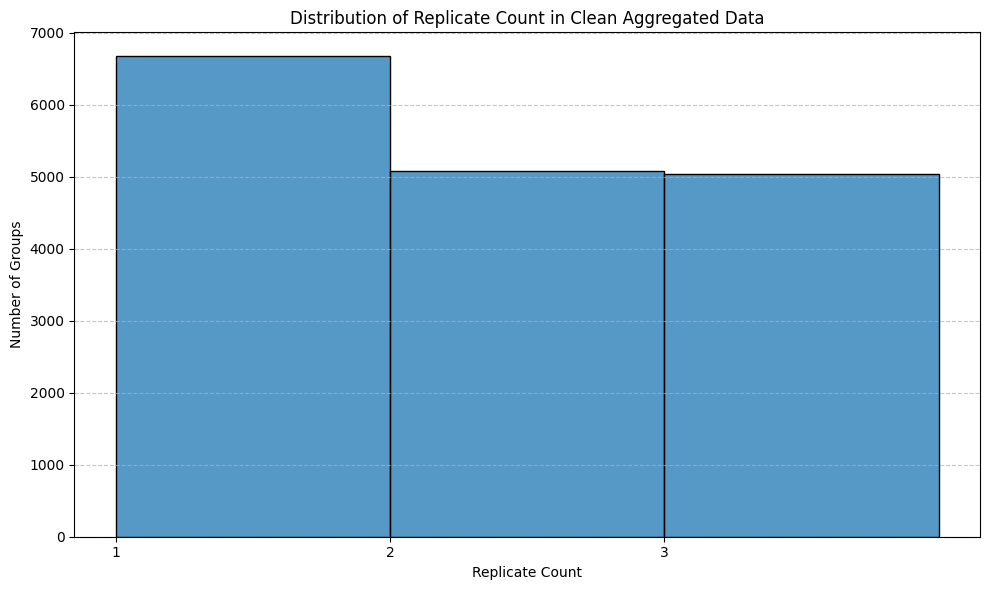

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(clean_aggregated_df['replicate_count'], bins=range(1, clean_aggregated_df['replicate_count'].max() + 2), kde=False, stat='count')
plt.title('Distribution of Replicate Count in Clean Aggregated Data')
plt.xlabel('Replicate Count')
plt.ylabel('Number of Groups')
plt.xticks(range(1, clean_aggregated_df['replicate_count'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 6))
# sns.histplot(df_plot['replicate_count'], bins=range(1, df_plot['replicate_count'].max() + 2), kde=False, stat='count')
# plt.title('Distribution of Replicate Count in Clean Aggregated Data')
# plt.xlabel('Replicate Count')
# plt.ylabel('Number of Groups')
# plt.xticks(range(1, df_plot['replicate_count'].max() + 1))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [ ]:
import os
import pandas as pd

output_dir = '/content/drive/MyDrive/Downstream/'
output_filename = 'clean_aggregated_with_high_var.parquet'
output_filepath = os.path.join(output_dir, output_filename)

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to a parquet file
clean_aggregated_df.to_parquet(output_filepath, engine='pyarrow', index=False)

print(f"'clean_aggregated_df' successfully saved to '{output_filepath}'.")


'clean_aggregated_df' successfully saved to '/content/drive/MyDrive/Downstream/clean_aggregated_with_high_var.parquet'.


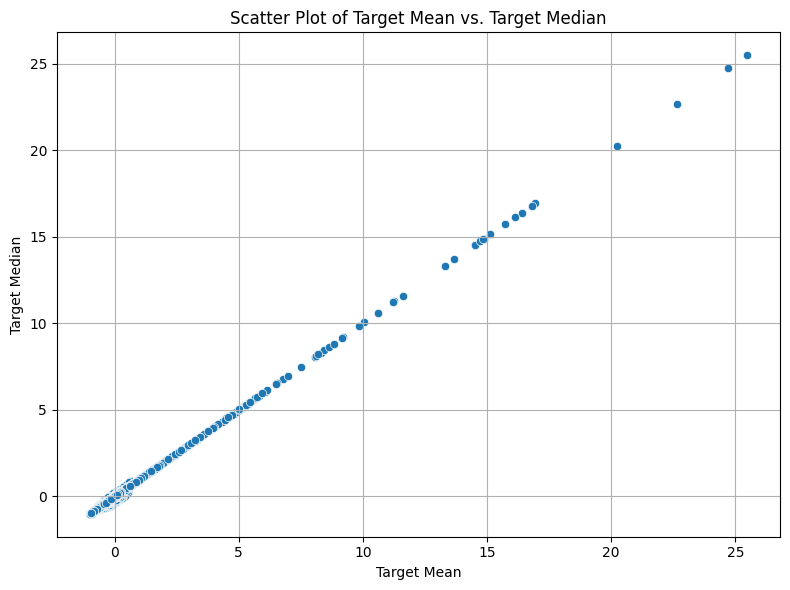

<class 'pandas.core.frame.DataFrame'>
Index: 16783 entries, 0 to 16812
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   group_identifier   16783 non-null  object 
 1   target_mean        16783 non-null  float64
 2   target_median      16783 non-null  float64
 3   target_sd          10109 non-null  float64
 4   replicate_count    16783 non-null  int64  
 5   high_noise_flag    16783 non-null  bool   
 6   sequence           16783 non-null  object 
 7   mutations          16783 non-null  object 
 8   sequences_mutated  16783 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 1.2+ MB


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(x='target_mean', y='target_median', data=clean_aggregated_df)
plt.title('Scatter Plot of Target Mean vs. Target Median')
plt.xlabel('Target Mean')
plt.ylabel('Target Median')
plt.grid(True)
plt.tight_layout()
plt.show()
clean_aggregated_df.info()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

output_dir = '/content/drive/MyDrive/Downstream/'
output_parquet_path = os.path.join(output_dir, 'clean_aggregated_with_high_var.parquet')

clean_aggregated_df = pd.read_parquet(output_parquet_path)

print(f"'clean_aggregated_df' successfully loaded from '{output_parquet_path}'.")
print(f"Shape of clean_aggregated_df: {clean_aggregated_df.shape}")
print("First 5 rows of clean_aggregated_df:")
print(clean_aggregated_df.info())

'clean_aggregated_df' successfully loaded from '/content/drive/MyDrive/Downstream/clean_aggregated_with_high_var.parquet'.
Shape of clean_aggregated_df: (16783, 9)
First 5 rows of clean_aggregated_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16783 entries, 0 to 16782
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   group_identifier   16783 non-null  object 
 1   target_mean        16783 non-null  float64
 2   target_median      16783 non-null  float64
 3   target_sd          10109 non-null  float64
 4   replicate_count    16783 non-null  int64  
 5   high_noise_flag    16783 non-null  bool   
 6   sequence           16783 non-null  object 
 7   mutations          16783 non-null  object 
 8   sequences_mutated  16783 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 1.0+ MB
None


In [ ]:
# import pandas as pd
# import os

# # Define the path to the parquet file (assuming output_dir is already set)
# output_dir = '/content/drive/MyDrive/Downstream/'
# sa_tokens_parquet_path = os.path.join(output_dir, 'clean_aggregated_with_sa_tokens.parquet')

# # Load the DataFrame to ensure it's defined and up-to-date
# clean_aggregated_df_with_sa_tokens = pd.read_parquet(sa_tokens_parquet_path)

# initial_rows_sa_tokens = len(clean_aggregated_df_with_sa_tokens)
# clean_aggregated_df_with_sa_tokens.dropna(subset=['sa_tokens'], inplace=True)
# rows_dropped_sa_tokens = initial_rows_sa_tokens - len(clean_aggregated_df_with_sa_tokens)
# print(f"Dropped {rows_dropped_sa_tokens} rows from clean_aggregated_df_with_sa_tokens where 'sa_tokens' was NaN.")
# print(f"New shape of clean_aggregated_df_with_sa_tokens: {clean_aggregated_df_with_sa_tokens.shape}")

# # Save the cleaned DataFrame back to the parquet file
# clean_aggregated_df_with_sa_tokens.to_parquet(sa_tokens_parquet_path, engine='pyarrow', index=False)
# print(f"'clean_aggregated_df_with_sa_tokens' successfully saved to '{sa_tokens_parquet_path}' after dropping rows with NaN 'sa_tokens'.")


In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration, AutoModel, AutoTokenizer
import re
import pandas as pd
import os # Import os for path operations

# Setup Devices (ensure consistency, using 'cuda' if available, otherwise 'cpu')
# If CUDA OOMs, fallback to CPU for ProstT5 as well
prost_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#1. Load ProstT5 (Translation: AA -> 3Di)
prost_model_name = "Rostlab/ProstT5"
prost_tokenizer = T5Tokenizer.from_pretrained(prost_model_name, do_lower_case=False)
prost_model = T5ForConditionalGeneration.from_pretrained(prost_model_name).to(prost_device).eval()

print("ProstT5 model and tokenizer loaded.")

# Define get_3di_tokens (copied from earlier cell for self-containment if needed)
def get_3di_tokens(sequence):
    processed_seq = " ".join(list(re.sub(r"[UZOB]", "X", sequence.upper())))
    input_str = f"<AA2fold> {processed_seq}"
    input_ids = prost_tokenizer(input_str, return_tensors="pt").input_ids.to(prost_device)
    with torch.no_grad():
        output_ids = prost_model.generate(input_ids, max_length=len(sequence) + 2)
    tokens_3di = prost_tokenizer.decode(output_ids[0], skip_special_tokens=True).replace(" ", "")
    return tokens_3di

def generate_sa_tokens_for_df(input_df_chunk, sequence_column_name, batch_size=16):
    """
    Generates SA-tokens for sequences in a specified column of a DataFrame chunk using ProstT5.

    Args:
        input_df_chunk (pd.DataFrame): The DataFrame chunk containing protein sequences.
        sequence_column_name (str): The name of the column in input_df_chunk that contains the sequences.
        batch_size (int): Batch size for processing sequences within the chunk.

    Returns:
        pd.DataFrame: The input DataFrame chunk with a new 'sa_tokens' column.
    """
    sa_tokens_list = []

    # Check if the sequence_column_name exists
    if sequence_column_name not in input_df_chunk.columns:
        raise ValueError(f"Sequence column '{sequence_column_name}' not found in the DataFrame chunk.")

    # Process in batches for speed and memory efficiency
    for i in range(0, len(input_df_chunk), batch_size):
        batch_seqs_df = input_df_chunk.iloc[i : i + batch_size].copy()
        sequences_batch = batch_seqs_df[sequence_column_name].tolist()

        batch_sa_seqs = []
        for seq in sequences_batch:
            if pd.isna(seq) or not isinstance(seq, str): # Handle potential NaN, None or non-string values
                batch_sa_seqs.append(None)
                continue
            try:
                tokens_3di = get_3di_tokens(seq)
                sa_seq = "".join([f"{aa}{st}" for aa, st in zip(seq.upper(), tokens_3di.lower())])
                batch_sa_seqs.append(sa_seq)
            except Exception as e:
                print(f"Error processing sequence '{seq[:20]}...' from column '{sequence_column_name}': {e}")
                batch_sa_seqs.append(None)

        sa_tokens_list.extend(batch_sa_seqs)

    input_df_chunk['sa_tokens'] = sa_tokens_list
    return input_df_chunk

# --- Incremental SA-token Generation for clean_aggregated_df ---

output_dir = '/content/drive/MyDrive/Downstream/' # Ensure output_dir is defined
sa_tokens_parquet_path = os.path.join(output_dir, 'clean_aggregated_with_sa_tokens.parquet')

processed_sa_tokens_df = pd.DataFrame()
if os.path.exists(sa_tokens_parquet_path):
    print(f"'{sa_tokens_parquet_path}' found. Loading existing SA-tokens...")
    processed_sa_tokens_df = pd.read_parquet(sa_tokens_parquet_path)
    print(f"Loaded {len(processed_sa_tokens_df)} existing SA-token entries.")

    # Identify entries in clean_aggregated_df that have not yet been processed
    # We use 'group_identifier' to match
    processed_group_identifiers = set(processed_sa_tokens_df['group_identifier'].unique())
    new_entries_to_process = clean_aggregated_df[~clean_aggregated_df['group_identifier'].isin(processed_group_identifiers)].copy()
    print(f"Identified {len(new_entries_to_process)} new entries in clean_aggregated_df to process for SA-tokens.")
else:
    print(f"'{sa_tokens_parquet_path}' not found. All entries in clean_aggregated_df will be processed for SA-tokens.")
    new_entries_to_process = clean_aggregated_df.copy()

save_interval_sa_tokens = 25 # Define the save interval for SA-tokens as requested

if not new_entries_to_process.empty:
    print("Processing new entries for SA-tokens incrementally...")
    processed_count_current_session = 0
    total_new_entries = len(new_entries_to_process)

    for i in range(0, total_new_entries, save_interval_sa_tokens):
        chunk_to_process = new_entries_to_process.iloc[i : i + save_interval_sa_tokens].copy()

        # Generate SA-tokens for the current chunk
        processed_chunk_with_sa_tokens = generate_sa_tokens_for_df(
            chunk_to_process,
            sequence_column_name='sequences_mutated',
            batch_size=16 # Using the batch_size defined in generate_sa_tokens_for_df
        )

        # Combine with previously processed data from the file for checkpointing
        # Load latest from disk to ensure consistency if multiple runs, or start with an empty DataFrame
        current_parquet_sa_tokens_df = pd.DataFrame()
        if os.path.exists(sa_tokens_parquet_path):
            current_parquet_sa_tokens_df = pd.read_parquet(sa_tokens_parquet_path)

        # Append new processed chunk
        temp_final_sa_tokens_df = pd.concat([current_parquet_sa_tokens_df, processed_chunk_with_sa_tokens], ignore_index=True)

        # Overwrite the parquet file with the combined data
        temp_final_sa_tokens_df.to_parquet(sa_tokens_parquet_path, engine='pyarrow', index=False)

        processed_count_current_session += len(processed_chunk_with_sa_tokens)
        print(f"Processed {processed_count_current_session}/{total_new_entries} new entries for SA-tokens. Checkpoint saved to '{sa_tokens_parquet_path}'. Total entries so far: {len(temp_final_sa_tokens_df)}")

    clean_aggregated_df_with_sa_tokens = pd.read_parquet(sa_tokens_parquet_path)
    print(f"Finished processing all new entries for SA-tokens. Final data saved to '{sa_tokens_parquet_path}'. Total entries: {len(clean_aggregated_df_with_sa_tokens)}")
else:
    print("No new entries in clean_aggregated_df to process for SA-tokens. Data is up to date.")
    clean_aggregated_df_with_sa_tokens = processed_sa_tokens_df # If no new sequences, final_df is just the existing_df

print("\nFinal DataFrame 'clean_aggregated_df_with_sa_tokens' ready.")
print(clean_aggregated_df_with_sa_tokens[['group_identifier', 'sequences_mutated', 'sa_tokens', 'target_median']].head())
print("\nInfo of clean_aggregated_df_with_sa_tokens:")
clean_aggregated_df_with_sa_tokens.info()

Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

output_dir = '/content/drive/MyDrive/Downstream/'
output_parquet_path = os.path.join(output_dir, 'clean_aggregated_with_sa_tokens.parquet')

clean_aggregated_with_sa_tokens_df = pd.read_parquet(output_parquet_path)

print(f"'clean_aggregated_with_sa_tokens_df' successfully loaded from '{output_parquet_path}'.")
print(f"Shape of clean_aggregated_with_sa_tokens_df: {clean_aggregated_with_sa_tokens_df.shape}")
print("First 5 rows of clean_aggregated_with_sa_tokens_df:")
print(len(clean_aggregated_with_sa_tokens_df.sa_tokens.unique()))

'clean_aggregated_with_sa_tokens_df' successfully loaded from '/content/drive/MyDrive/Downstream/clean_aggregated_with_sa_tokens.parquet'.
Shape of clean_aggregated_with_sa_tokens_df: (16783, 47)
First 5 rows of clean_aggregated_with_sa_tokens_df:
16783


In [ ]:
clean_aggregated_with_sa_tokens_df.processed_score.dropna(inplace=True)

<Axes: xlabel='target_mean', ylabel='target_median'>

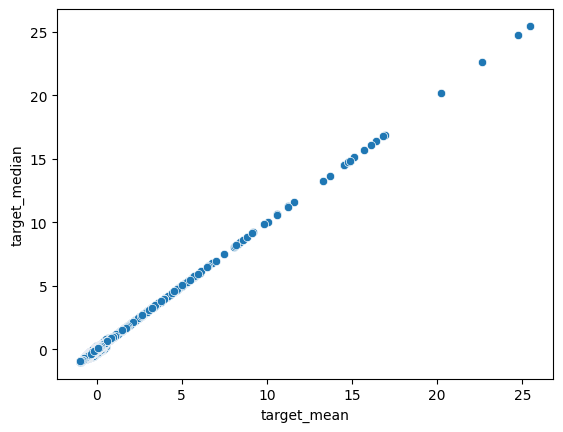

In [ ]:
import seaborn as sns
sns.scatterplot(x='target_mean', y='target_median', data=clean_aggregated_with_sa_tokens_df)

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# import matplotlib.pyplot as plt
# import seaborn as sns

# if not clean_aggregated_with_sa_tokens_df.empty and 'target_median' in clean_aggregated_with_sa_tokens_df.columns:
#     # Drop NaN values from 'target_median' for scaling, or fill them if appropriate for the task.
#     # For Min-Max, NaN values will be ignored in fit_transform and remain NaN.
#     # We'll create a temporary series for scaling to avoid modifying the original column's NaNs directly
#     target_median_present = clean_aggregated_with_sa_tokens_df['target_median'].dropna().values.reshape(-1, 1)

#     if target_median_present.size > 0:
#         scaler_median = MinMaxScaler(feature_range=(-1, 1)) # Use MinMaxScaler with feature_range=(-1, 1)
#         # Fit and transform only the non-NaN values
#         scaled_values_median = scaler_median.fit_transform(target_median_present)

#         # Create a new series with the same index as the original 'target_median' column
#         # and fill non-NaN positions with scaled values, keeping NaNs as they are
#         scaled_target_median = clean_aggregated_with_sa_tokens_df['target_median'].copy()
#         scaled_target_median[~clean_aggregated_with_sa_tokens_df['target_median'].isna()] = scaled_values_median.flatten()

#         clean_aggregated_with_sa_tokens_df['target_median_scaled_minmax'] = scaled_target_median # New column name

#         print("\n'target_median' column normalized using Min-Max scaler (-1 to 1) and stored in 'target_median_scaled_minmax'.")
#         print("First 5 rows with original and scaled target_median:")
#         print(clean_aggregated_with_sa_tokens_df[['target_median', 'target_median_scaled_minmax']].head()) # Display new column
#         print("\nDescriptive statistics for 'target_median_scaled_minmax':")
#         print(clean_aggregated_with_sa_tokens_df['target_median_scaled_minmax'].describe())

#         # --- Plotting the scaled data ---
#         # Drop rows where either target_median or target_median_scaled_minmax is NaN for plotting clarity
#         plot_df_median = clean_aggregated_with_sa_tokens_df.dropna(subset=['target_median', 'target_median_scaled_minmax']).copy()

#         plt.figure(figsize=(10, 8))
#         sns.scatterplot(x='target_median', y='target_median_scaled_minmax', data=plot_df_median, alpha=0.7)

#         # Add a title and labels for clarity
#         plt.title('Original Target Median vs. Min-Max Scaled Target Median (-1 to 1)')
#         plt.xlabel('Original Target Median')
#         plt.ylabel('Min-Max Scaled Target Median (-1 to 1)')

#         # Add a diagonal line to show the general trend of transformation, if applicable
#         min_val = min(plot_df_median['target_median'].min(), plot_df_median['target_median_scaled_minmax'].min())
#         max_val = max(plot_df_median['target_median'].max(), plot_df_median['target_median_scaled_minmax'].max())
#         plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Linear Transformation Trend')

#         plt.grid(True)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

#     else:
#         print("The 'target_median' column contains no non-null values to scale.")
# else:
#     print("DataFrame 'clean_aggregated_with_sa_tokens_df' is empty or 'target_median' column not found. Cannot perform Min-Max normalization.")


In [ ]:
# initial_rows_with_nan_final = len(clean_aggregated_with_sa_tokens_df)
# clean_aggregated_with_sa_tokens_df.dropna(subset=['target_median_scaled_minmax', 'sa_tokens'], inplace=True)
# rows_dropped_final = initial_rows_with_nan_final - len(clean_aggregated_with_sa_tokens_df)

# print(f"Dropped {rows_dropped_final} rows from clean_aggregated_with_sa_tokens_df due to NaN values in 'target_median_scaled_minmax' or 'sa_tokens'.")
# print(f"New shape of clean_aggregated_with_sa_tokens_df: {clean_aggregated_with_sa_tokens_df.shape}")
# print("First 5 rows of the final cleaned clean_aggregated_with_sa_tokens_df:")
# print(clean_aggregated_with_sa_tokens_df.info())


'target_median' column normalized using StandardScaler (Z-score) and stored in 'target_median_scaled_standard'.
First 5 rows with original and standardized target_median:
   target_median  target_median_scaled_standard
0      -0.236712                      -0.150008
1      -0.240775                      -0.154701
2      -0.096435                       0.012045
3      -0.425890                      -0.368553
4      -0.375489                      -0.310328

Descriptive statistics for 'target_median_scaled_standard':
count    1.678300e+04
mean     7.620669e-18
std      1.000030e+00
min     -1.031784e+00
25%     -3.343935e-01
50%     -9.165685e-02
75%      1.217697e-01
max      2.955622e+01
Name: target_median_scaled_standard, dtype: float64


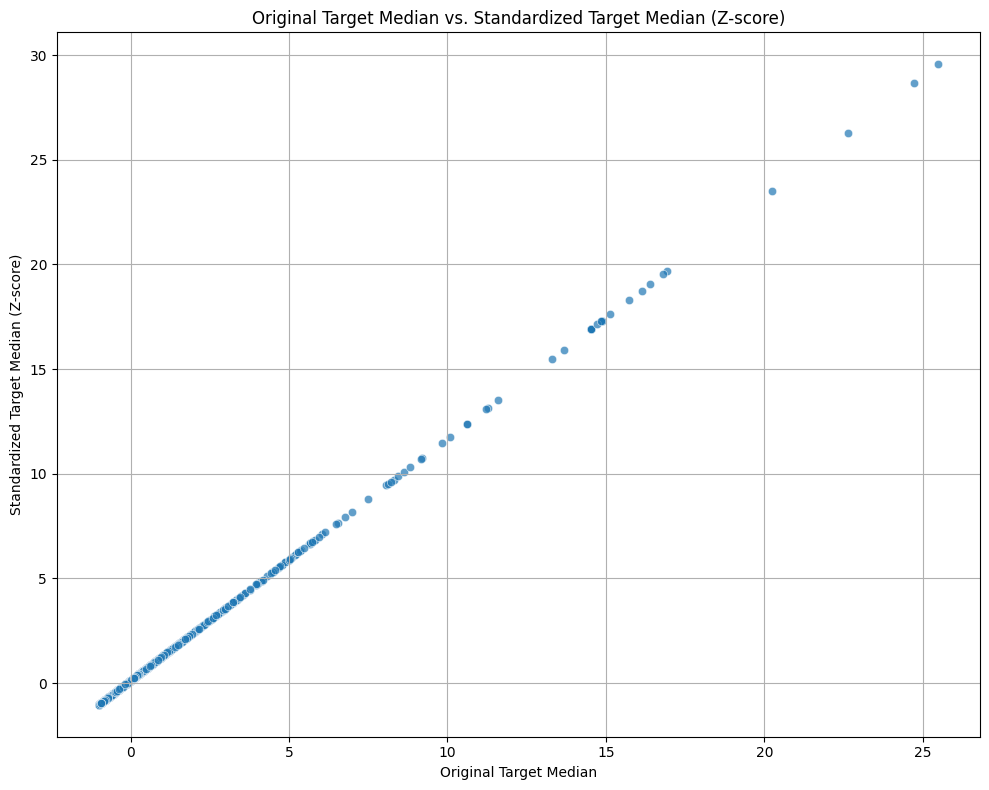

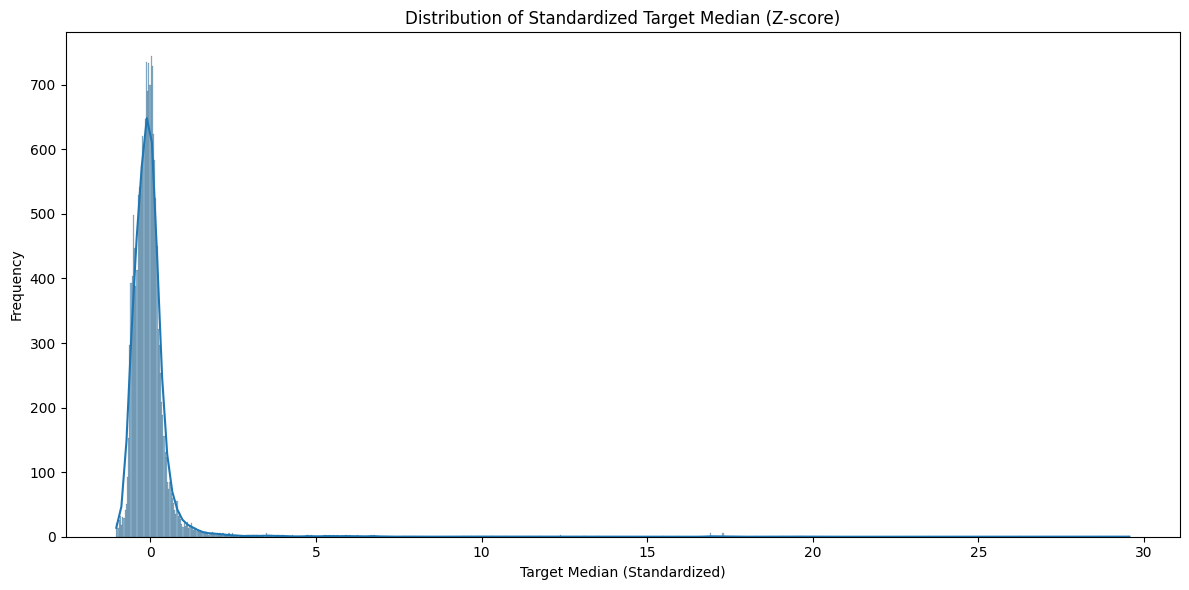

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

if not clean_aggregated_with_sa_tokens_df.empty and 'target_median' in clean_aggregated_with_sa_tokens_df.columns:
    # Initialize StandardScaler
    scaler_standard = StandardScaler()

    # Drop NaN values from 'target_median' for scaling, or fill them if appropriate for the task.
    target_median_present = clean_aggregated_with_sa_tokens_df['target_median'].dropna().values.reshape(-1, 1)

    if target_median_present.size > 0:
        # Fit and transform only the non-NaN values
        scaled_values_standard = scaler_standard.fit_transform(target_median_present)

        # Create a new series with the same index as the original 'target_median' column
        scaled_target_median_standard = clean_aggregated_with_sa_tokens_df['target_median'].copy()
        scaled_target_median_standard[~clean_aggregated_with_sa_tokens_df['target_median'].isna()] = scaled_values_standard.flatten()

        clean_aggregated_with_sa_tokens_df['target_median_scaled_standard'] = scaled_target_median_standard # New column name

        print("\n'target_median' column normalized using StandardScaler (Z-score) and stored in 'target_median_scaled_standard'.")
        print("First 5 rows with original and standardized target_median:")
        print(clean_aggregated_with_sa_tokens_df[['target_median', 'target_median_scaled_standard']].head())
        print("\nDescriptive statistics for 'target_median_scaled_standard':")
        print(clean_aggregated_with_sa_tokens_df['target_median_scaled_standard'].describe())

        # --- Plotting the scaled data ---
        plot_df_standard = clean_aggregated_with_sa_tokens_df.dropna(subset=['target_median', 'target_median_scaled_standard']).copy()

        plt.figure(figsize=(10, 8))
        sns.scatterplot(x='target_median', y='target_median_scaled_standard', data=plot_df_standard, alpha=0.7)

        plt.title('Original Target Median vs. Standardized Target Median (Z-score)')
        plt.xlabel('Original Target Median')
        plt.ylabel('Standardized Target Median (Z-score)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 6))
        sns.histplot(clean_aggregated_with_sa_tokens_df['target_median_scaled_standard'], kde=True)
        plt.title('Distribution of Standardized Target Median (Z-score)')
        plt.xlabel('Target Median (Standardized)')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    else:
        print("The 'target_median' column contains no non-null values to scale.")
else:
    print("DataFrame 'clean_aggregated_with_sa_tokens_df' is empty or 'target_median' column not found. Cannot perform Standardization.")


### Enhanced Normalization Strategy: Yeo-Johnson Transformation + Standardization

To further address the skewness and make the target distribution more Gaussian-like, especially with both positive and negative values, we will apply the **Yeo-Johnson power transformation** followed by **Standardization**.


'target_median' column transformed with Yeo-Johnson and then standardized (Z-score) and stored in 'target_median_scaled_yeojohnson_standard'.
First 5 rows with original and new transformed target_median:
   target_median  target_median_scaled_yeojohnson_standard
0      -0.236712                                 -0.036878
1      -0.240775                                 -0.050381
2      -0.096435                                  0.386843
3      -0.425890                                 -0.743075
4      -0.375489                                 -0.539136

Descriptive statistics for 'target_median_scaled_yeojohnson_standard':
count    1.678300e+04
mean     1.193905e-16
std      1.000030e+00
min     -3.963784e+00
25%     -6.220051e-01
50%      1.251189e-01
75%      6.287797e-01
max      4.007708e+00
Name: target_median_scaled_yeojohnson_standard, dtype: float64


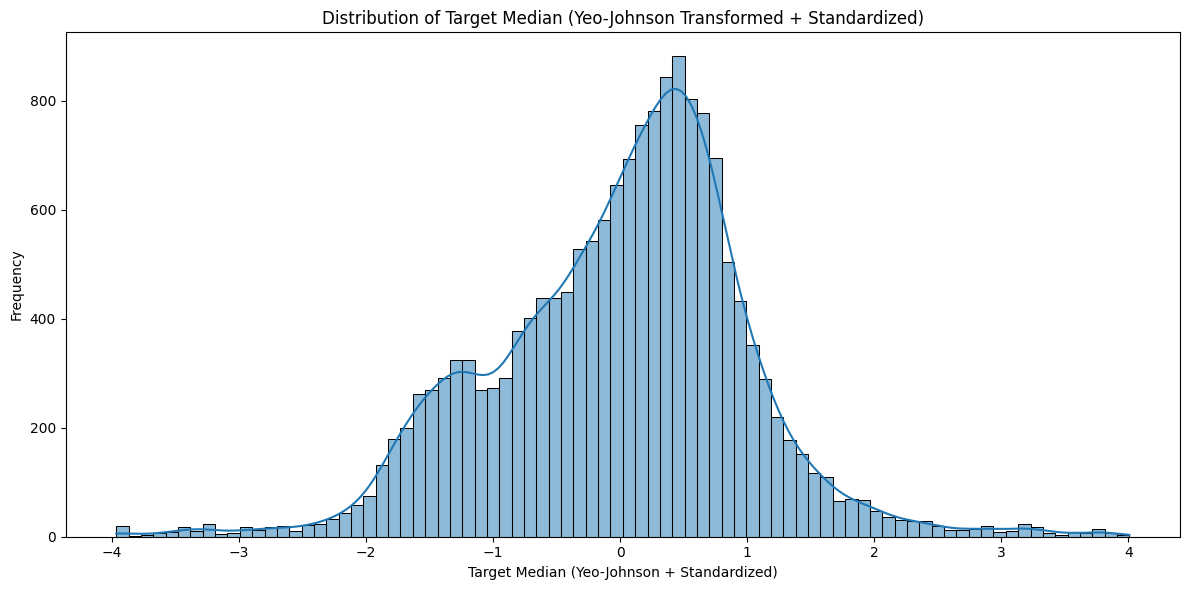

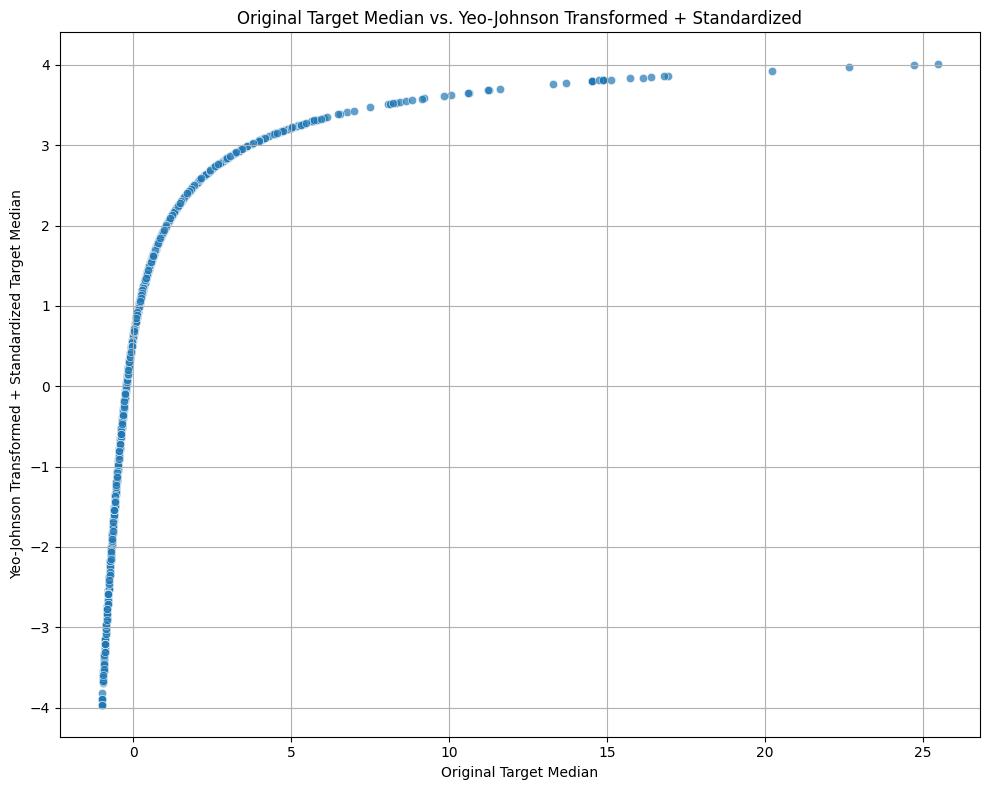

In [ ]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

if not clean_aggregated_with_sa_tokens_df.empty and 'target_median' in clean_aggregated_with_sa_tokens_df.columns:
    # Initialize Yeo-Johnson PowerTransformer
    yeo_johnson_transformer = PowerTransformer(method='yeo-johnson', standardize=False) # Do not standardize yet

    # Drop NaN values from 'target_median' for transformation
    target_median_present = clean_aggregated_with_sa_tokens_df['target_median'].dropna().values.reshape(-1, 1)

    if target_median_present.size > 0:
        # Fit and transform using Yeo-Johnson
        transformed_values_yeo_johnson = yeo_johnson_transformer.fit_transform(target_median_present)

        # Now apply StandardScaler to the Yeo-Johnson transformed values
        scaler_standard_yeojohnson = StandardScaler()
        scaled_values_yeojohnson_standard = scaler_standard_yeojohnson.fit_transform(transformed_values_yeo_johnson)

        # Create a new series with the same index as the original 'target_median' column
        scaled_target_median_yeojohnson_standard = clean_aggregated_with_sa_tokens_df['target_median'].copy()
        scaled_target_median_yeojohnson_standard[~clean_aggregated_with_sa_tokens_df['target_median'].isna()] = scaled_values_yeojohnson_standard.flatten()

        clean_aggregated_with_sa_tokens_df['target_median_scaled_yeojohnson_standard'] = scaled_target_median_yeojohnson_standard # New column name

        print("\n'target_median' column transformed with Yeo-Johnson and then standardized (Z-score) and stored in 'target_median_scaled_yeojohnson_standard'.")
        print("First 5 rows with original and new transformed target_median:")
        print(clean_aggregated_with_sa_tokens_df[['target_median', 'target_median_scaled_yeojohnson_standard']].head())
        print("\nDescriptive statistics for 'target_median_scaled_yeojohnson_standard':")
        print(clean_aggregated_with_sa_tokens_df['target_median_scaled_yeojohnson_standard'].describe())

        # --- Plotting the new scaled data --- General distribution plot
        plt.figure(figsize=(12, 6))
        sns.histplot(clean_aggregated_with_sa_tokens_df['target_median_scaled_yeojohnson_standard'], kde=True)
        plt.title('Distribution of Target Median (Yeo-Johnson Transformed + Standardized)')
        plt.xlabel('Target Median (Yeo-Johnson + Standardized)')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

        # Scatter plot of original vs. newly transformed
        plot_df_yeojohnson = clean_aggregated_with_sa_tokens_df.dropna(subset=['target_median', 'target_median_scaled_yeojohnson_standard']).copy()
        plt.figure(figsize=(10, 8))
        sns.scatterplot(x='target_median', y='target_median_scaled_yeojohnson_standard', data=plot_df_yeojohnson, alpha=0.7)
        plt.title('Original Target Median vs. Yeo-Johnson Transformed + Standardized')
        plt.xlabel('Original Target Median')
        plt.ylabel('Yeo-Johnson Transformed + Standardized Target Median')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
        print("The 'target_median' column contains no non-null values to transform.")
else:
    print("DataFrame 'clean_aggregated_with_sa_tokens_df' is empty or 'target_median' column not found. Cannot perform Yeo-Johnson transformation.")

In [ ]:
initial_rows_with_nan_final = len(clean_aggregated_with_sa_tokens_df)
clean_aggregated_with_sa_tokens_df.dropna(subset=['target_median_scaled_yeojohnson_standard', 'sa_tokens'], inplace=True)
rows_dropped_final = initial_rows_with_nan_final - len(clean_aggregated_with_sa_tokens_df)

print(f"Dropped {rows_dropped_final} rows from clean_aggregated_with_sa_tokens_df due to NaN values in 'target_median_scaled_minmax' or 'sa_tokens'.")
print(f"New shape of clean_aggregated_with_sa_tokens_df: {clean_aggregated_with_sa_tokens_df.shape}")
print("First 5 rows of the final cleaned clean_aggregated_with_sa_tokens_df:")
print(clean_aggregated_with_sa_tokens_df.info())

Dropped 0 rows from clean_aggregated_with_sa_tokens_df due to NaN values in 'target_median_scaled_minmax' or 'sa_tokens'.
New shape of clean_aggregated_with_sa_tokens_df: (16783, 49)
First 5 rows of the final cleaned clean_aggregated_with_sa_tokens_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16783 entries, 0 to 16782
Data columns (total 49 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   group_identifier                          16783 non-null  object 
 1   target_mean                               16783 non-null  float64
 2   target_median                             16783 non-null  float64
 3   target_sd                                 10109 non-null  float64
 4   replicate_count                           16783 non-null  int64  
 5   high_noise_flag                           16783 non-null  bool   
 6   sequence_x                                6275 non-null   object 

# **Building model and training**

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import EsmTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# 1. Set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Huber loss function will be used.
print("Huber  loss function will be used.")

# Assuming clean_aggregated_with_sa_tokens_df is already loaded

# For Huber, we only need the target_median
# No need to handle target_sd or calculate log_variance

# 3. Split clean_aggregated_with_sa_tokens_df into training, validation, and test sets
# First split: train vs. (val + test)
train_df, temp_df = train_test_split(
    clean_aggregated_with_sa_tokens_df,
    test_size=0.3, # 30% for val + test
    random_state=42
)

# Second split: val vs. test from the temporary dataframe
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5, # 50% of the temp_df goes to test, making it 15% of original
    random_state=42
)

print(f"Data split into train_df (shape: {train_df.shape}), val_df (shape: {val_df.shape}), and test_df (shape: {test_df.shape}).")

# 4. Initialize the EsmTokenizer
tokenizer = EsmTokenizer.from_pretrained("westlake-repl/SaProt_650M_AF2", do_lower_case=False)
print("ESM Tokenizer initialized.")

# 5. Create a custom PyTorch Dataset class
class ProteinSolubilityDataset(Dataset):
    def __init__(self, dataframe, tokenizer, sequence_column='sa_tokens',
                 target_column='target_median_scaled_yeojohnson_standard'): # Changed target column
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.sequence_column = sequence_column
        self.target_column = target_column

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        sequence = self.dataframe.loc[idx, self.sequence_column]
        target = self.dataframe.loc[idx, self.target_column]

        # For Huber, labels are just the single target value
        labels = torch.tensor(target, dtype=torch.float32) # Shape: ()
        return sequence, labels

print(f"ProteinSolubilityDataset class defined, using '{'target_median_scaled_yeojohnson_standard'}' as target.")

# 6. Instantiate ProteinSolubilityDataset for train_df, val_df, and test_df
train_dataset = ProteinSolubilityDataset(train_df, tokenizer)
val_dataset = ProteinSolubilityDataset(val_df, tokenizer)
test_dataset = ProteinSolubilityDataset(test_df, tokenizer)

print("Train, validation, and test datasets instantiated.")

# 7. Create PyTorch DataLoader instances
def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels_raw = [item[1] for item in batch] # Each item[1] is now a single value tensor

    # Tokenize the batch of sequences. Padding to the longest in batch, truncation if needed.
    encoded_inputs = tokenizer(
        sequences,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=tokenizer.model_max_length # Use model's max length
    )

    # Stack the labels to create a tensor of shape (batch_size,) or (batch_size, 1)
    labels = torch.stack(labels_raw).unsqueeze(1) # Ensure labels are (batch_size, 1) for consistency

    # input_ids: A tensor of shape (Batch, L) containing the combined structural-sequence IDs.
    # attention_mask: A tensor of shape (Batch, L) to handle padding.
    return {
        'input_ids': encoded_inputs['input_ids'].to(device),
        'attention_mask': encoded_inputs['attention_mask'].to(device),
        'labels': labels.to(device) # Labels should be (batch_size, 1) for Huber
    }

# Define batch_size (can be adjusted)
batch_size = 2 # Reduced batch size to mitigate CUDA out of memory errors

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

print("DataLoaders ready.")

Using device: cuda
Huber  loss function will be used.
Data split into train_df (shape: (11748, 49)), val_df (shape: (2517, 49)), and test_df (shape: (2518, 49)).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

ESM Tokenizer initialized.
ProteinSolubilityDataset class defined, using 'target_median_scaled_yeojohnson_standard' as target.
Train, validation, and test datasets instantiated.
DataLoaders ready.


In [ ]:
import torch.nn as nn

def huber_loss(predictions, targets, delta=0.1):
    """
    Computes Huber loss.
    predictions: Tensor of shape (batch, 1) -> [predicted_mean]
    targets: Tensor of shape (batch, 1) -> [true_solubility]
    delta: The threshold at which to change between MSE and MAE.
    """
    return nn.functional.huber_loss(predictions.squeeze(), targets.squeeze(), delta=delta)

print("Huber loss function defined with adjusted delta.")

Huber loss function defined with adjusted delta.


In [ ]:
!pip install --upgrade torchao
import torch.nn as nn
from transformers import EsmForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

# Initialize the SaProt model
model_name = "westlake-repl/SaProt_650M_AF2"
model = EsmForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1, # Changed to 1 output for Median (for Huber Loss)
    trust_remote_code=True
)
model.to(device)

# Apply LoRA configuration
lora_config = LoraConfig(
    r=2, # Consistent with test script
    lora_alpha=4, # Consistent with test script
    target_modules=["query", "key", "value"], # Common target modules for attention layers
    task_type=TaskType.SEQ_CLS, # Specify the task type for LoRA
    lora_dropout=0.1
)

model = get_peft_model(model, lora_config)

print("SaProt model initialized with 1 output label (Median) and LoRA applied for Huber Loss.")
print(model.print_trainable_parameters())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/564 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

EsmForSequenceClassification LOAD REPORT from: westlake-repl/SaProt_650M_AF2
Key                                | Status     | 
-----------------------------------+------------+-
lm_head.dense.weight               | UNEXPECTED | 
lm_head.dense.bias                 | UNEXPECTED | 
lm_head.layer_norm.weight          | UNEXPECTED | 
lm_head.decoder.weight             | UNEXPECTED | 
lm_head.bias                       | UNEXPECTED | 
lm_head.layer_norm.bias            | UNEXPECTED | 
esm.embeddings.position_ids        | UNEXPECTED | 
esm.contact_head.regression.weight | MISSING    | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.bias              | MISSING    | 
esm.contact_head.regression.bias   | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly in

SaProt model initialized with 1 output label (Median) and LoRA applied for Huber Loss.
trainable params: 2,147,841 || all params: 653,718,423 || trainable%: 0.3286
None


In [ ]:
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from peft import PeftModel # Import PeftModel for loading adapter

# Use the huber_loss defined previously

# 1. Define the output directory and file paths
output_dir_model = '/content/drive/MyDrive/Downstream/'
model_save_path = os.path.join(output_dir_model, 'model_checkpoint_huber.pt') # New path for Huber model
lora_weights_save_path = os.path.join(output_dir_model, 'lora_weights_huber') # New path for Huber weights
loss_history_path = os.path.join(output_dir_model, 'training_losses_huber.pt') # New path for Huber losses

# Ensure the output directory exists
os.makedirs(output_dir_model, exist_ok=True)
os.makedirs(lora_weights_save_path, exist_ok=True) # Ensure LoRA weights directory exists

# 2. Load any existing training and validation loss history
train_losses = []
val_losses = []
if os.path.exists(loss_history_path):
    print(f"Loading existing loss history from '{loss_history_path}'.")
    history = torch.load(loss_history_path)
    train_losses = history['train_losses']
    val_losses = history['val_losses']
    print(f"Loaded {len(train_losses)} epochs of loss history.")

# Training parameters
num_epochs = 50 # Set to 50 epochs as a reasonable default for fine-tuning
learning_rate = 0.0001
warmup_steps = 0 # No warmup for simplicity, can be adjusted

# Initialize optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

total_steps = len(train_dataloader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Optimizer and scheduler initialized.")
print(f"Total training steps: {total_steps}")

# 3. Define early stopping parameters
patience = 10 # Increased patience for new model
min_delta = 0.0001 # minimum change in the monitored quantity to qualify as an improvement

# 4. Initialize early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0

# Determine starting epoch for resuming training
start_epoch = len(train_losses)
if start_epoch > 0:
    print(f"Resuming training from epoch {start_epoch + 1}.")
    # If resuming, load the best model state if it exists to continue from the best point
    if os.path.exists(lora_weights_save_path) and len(os.listdir(lora_weights_save_path)) > 0:
        # Load LoRA weights into the existing model
        try:
            model.load_adapter(lora_weights_save_path, adapter_name="default")
            print(f"Loaded LoRA weights for resuming training from '{lora_weights_save_path}'.")
        except Exception as e:
            print(f"Warning: Could not load LoRA adapter for resuming training from '{lora_weights_save_path}': {e}. Attempting to load full model state if available.")
            if os.path.exists(model_save_path):
                model.load_state_dict(torch.load(model_save_path, map_location=device))
                print(f"Loaded best full model state from '{model_save_path}' as a fallback.")
            else:
                print("No previous model state (LoRA or full) found for resumption.")
    elif os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        print(f"Loaded best full model state from '{model_save_path}'.")
    else:
        print("No previous model state found for resumption.")

    # Update best_val_loss based on previous history for comparison
    if len(val_losses) > 0:
        best_val_loss = min(val_losses) # Or val_losses[-1] if we want to continue from the last point
        print(f"Initialized best_val_loss from history: {best_val_loss:.4f}")

# Training loop
for epoch in range(start_epoch, num_epochs):
    model.train() # Set model to training mode
    total_train_loss = 0
    for batch_idx, batch in enumerate(tqdm.tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) # labels are (batch_size, 1) for Huber

        # Debugging: Check for NaNs/Infs in inputs/labels
        if torch.isnan(input_ids).any() or torch.isinf(input_ids).any():
            print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN or Inf found in input_ids!")
        if torch.isnan(attention_mask).any() or torch.isinf(attention_mask).any():
            print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN or Inf found in attention_mask!")
        if torch.isnan(labels).any() or torch.isinf(labels).any():
            print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN or Inf found in labels! Values: {labels}")

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits # Predictions will be (batch_size, 1) -> [mean_pred]

        # Debugging: Check for NaNs/Infs in predictions
        if torch.isnan(predictions).any() or torch.isinf(predictions).any():
            print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN or Inf found in predictions! Values: {predictions}")

        loss = huber_loss(predictions, labels) # Using Huber loss

        if torch.isnan(loss).any(): # Check if loss is NaN itself
            print(f"Epoch {epoch+1}, Batch {batch_idx}: Loss is NaN! Predictions: {predictions.squeeze()}, Labels: {labels.squeeze()}")
            # If loss is NaN, it will propagate. We should investigate further.
            # For now, we'll let it propagate to observe the first occurrence.

        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)

    # Evaluation loop
    model.eval() # Set model to evaluation mode
    total_val_loss = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for batch_idx, batch in enumerate(tqdm.tqdm(val_dataloader, desc=f"Validation Epoch {epoch+1}")):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device) # labels are (batch_size, 1) for Huber

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = outputs.logits # Predictions will be (batch_size, 1) -> [mean_pred]

            # Debugging: Check for NaNs/Infs in validation predictions
            if torch.isnan(predictions).any() or torch.isinf(predictions).any():
                print(f"Epoch {epoch+1}, Val Batch {batch_idx}: NaN or Inf found in validation predictions! Values: {predictions}")

            loss = huber_loss(predictions, labels) # Using Huber loss

            if torch.isnan(loss).any(): # Check if validation loss is NaN
                print(f"Epoch {epoch+1}, Val Batch {batch_idx}: Validation Loss is NaN! Predictions: {predictions.squeeze()}, Labels: {labels.squeeze()}")

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)

    # 5. Append losses and save history
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Save current loss history (checkpointing)
    torch.save({
        'train_losses': train_losses,
        'val_losses': val_losses
    }, loss_history_path)
    print(f"Loss history checkpointed to '{loss_history_path}'.")

    print(f"Epoch {epoch+1} - Average Training Loss: {avg_train_loss:.4f} - Average Validation Loss: {avg_val_loss:.4f}")

    # Early stopping logic
    if avg_val_loss < best_val_loss - min_delta:
        print(f"Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving LoRA weights...")
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        model.save_pretrained(lora_weights_save_path) # Save only LoRA weights
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve. Epochs without improvement: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {patience} epochs without improvement.")
        break

print("Training and evaluation complete.")

# Plotting after all epochs are done
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (Huber Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True)
plt.show()

# Rolling Average Plotting
# Define a window size for the rolling average
window_size = 3  # You can adjust this value

# Calculate rolling average for training losses
rolling_avg_train_losses = pd.Series(train_losses).rolling(window=window_size).mean()

# Calculate rolling average for validation losses
rolling_avg_val_losses = pd.Series(val_losses).rolling(window=window_size).mean()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rolling_avg_train_losses) + 1), rolling_avg_train_losses, label=f'Rolling Avg Training Loss (Window={window_size})')
plt.plot(range(1, len(rolling_avg_val_losses) + 1), rolling_avg_val_losses, label=f'Rolling Avg Validation Loss (Window={window_size})')
plt.title(f'Rolling Average of Training and Validation Loss Over Epochs (Window={window_size})')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True)
plt.show()

Loading existing loss history from '/content/drive/MyDrive/Downstream/training_losses_huber.pt'.
Loaded 7 epochs of loss history.
Optimizer and scheduler initialized.
Total training steps: 293700
Resuming training from epoch 8.
Loaded LoRA weights for resuming training from '/content/drive/MyDrive/Downstream/lora_weights_huber'.
Initialized best_val_loss from history: 0.0539


Validation Epoch 8: 100%|██████████| 1259/1259 [10:57<00:00,  1.91it/s]


Loss history checkpointed to '/content/drive/MyDrive/Downstream/training_losses_huber.pt'.
Epoch 8 - Average Training Loss: 0.0519 - Average Validation Loss: 0.0535
Validation loss improved from 0.0539 to 0.0535. Saving LoRA weights...


Training Epoch 9:   4%|▎         | 219/5874 [04:00<1:43:26,  1.10s/it]


KeyboardInterrupt: 

Making predictions on test data...


Predicting on Test Data: 100%|██████████| 1259/1259 [10:59<00:00,  1.91it/s]


Predictions complete.


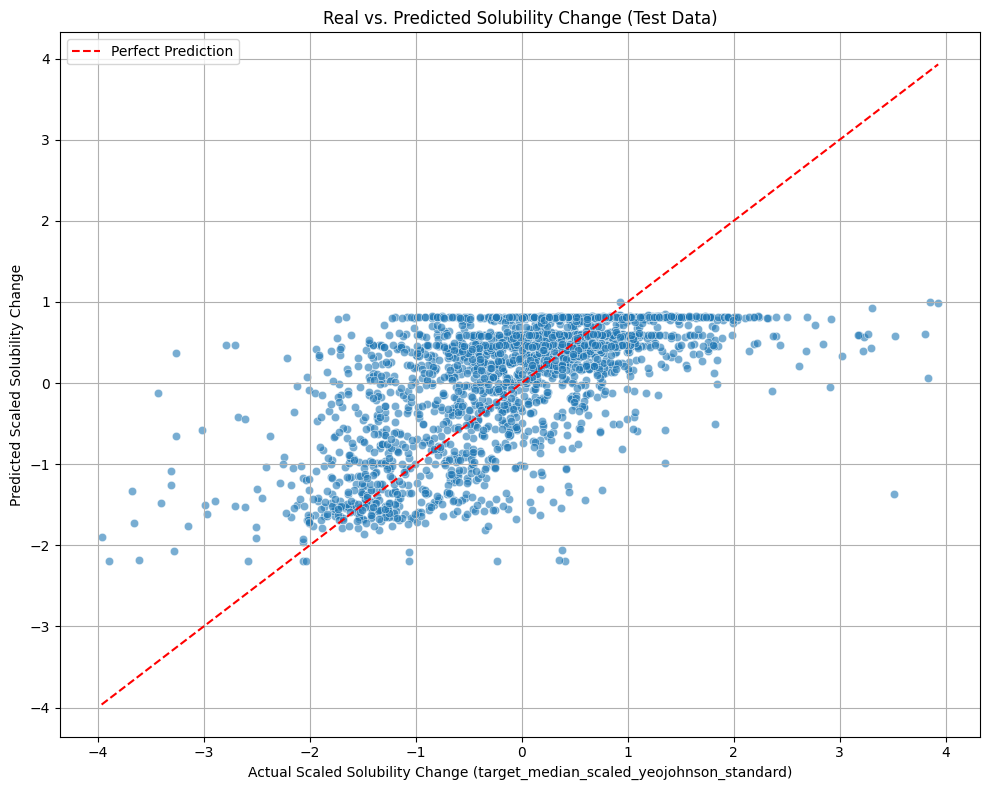

Pearson Correlation Coefficient: 0.6352
Spearman Correlation Coefficient: 0.6335


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Import pandas for spearman correlation calculation

# Load the best LoRA weights from the saved path
# Assuming `lora_weights_save_path` is defined and contains the best weights
# This makes sure we are evaluating the best performing model based on validation loss

# Ensure the model is moved to the correct device (CPU or GPU)
model.to(device)

# Set the model to evaluation mode
model.eval()

predictions_list = []
labels_list = []

print("Making predictions on test data...")

# Iterate over the test dataloader
with torch.no_grad(): # Disable gradient calculation
    for batch_idx, batch in enumerate(tqdm.tqdm(test_dataloader, desc="Predicting on Test Data")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits # Predictions will be (batch_size, 1) for Huber

        predictions_list.extend(predictions.cpu().numpy().flatten())
        labels_list.extend(labels.cpu().numpy().flatten())

print("Predictions complete.")

# Convert to numpy arrays for plotting
predictions_array = np.array(predictions_list)
labels_array = np.array(labels_list)

# Plotting Real vs. Predicted values
plt.figure(figsize=(10, 8))
sns.scatterplot(x=labels_array, y=predictions_array, alpha=0.6)

# Add a diagonal line for perfect prediction
min_val = min(labels_array.min(), predictions_array.min())
max_val = max(labels_array.max(), predictions_array.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Real vs. Predicted Solubility Change (Test Data)')
plt.xlabel('Actual Scaled Solubility Change (target_median_scaled_yeojohnson_standard)')
plt.ylabel('Predicted Scaled Solubility Change')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate correlation coefficients
pearson_corr = np.corrcoef(labels_array, predictions_array)[0, 1]
spearman_corr = np.array(pd.Series(labels_array).corr(pd.Series(predictions_array), method='spearman'))

print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
print(f"Spearman Correlation Coefficient: {spearman_corr:.4f}")

## Unload Model to Free Resources

In [ ]:
import gc

del model

torch.cuda.empty_cache()
gc.collect()

print("Model unloaded and memory cleared.")

Model unloaded and memory cleared.
